In [1]:
import os
from pathlib import Path
import pandas as pd
import json
import numpy as np
from PIL import Image

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [2]:
results_path = Path('results')
alignment_files = [f.relative_to(results_path) for f in results_path.rglob("*") if f.is_file() and "WCST_alignment.json" in f.name]

In [3]:
file_path = os.path.join(results_path, alignment_files[0])
with open(file_path, "r", encoding = "utf-8") as f:
    data = json.load(f)

state_path = alignment_files[0].with_name("WCST_test_data.npz")

In [5]:
state_data = np.load(os.path.join(results_path, state_path))
state_data = state_data['test_state']

state_2d = state_data
vecs_2d = data['log']['1']['epoch_vectors']

state_1d = [x for sublist in state_2d for x in sublist]
vecs_1d = [x for sublist in vecs_2d for x in sublist]

In [7]:
lda = LinearDiscriminantAnalysis(n_components = 2)
vecs_lda = lda.fit_transform(vecs_1d, state_1d)
vecs_lda_2d = vecs_lda.reshape(-1, 10, 2)

In [9]:
print(vecs_lda_2d.shape)
print(np.array(state_2d).shape)

(1000, 10, 2)
(1000, 10)


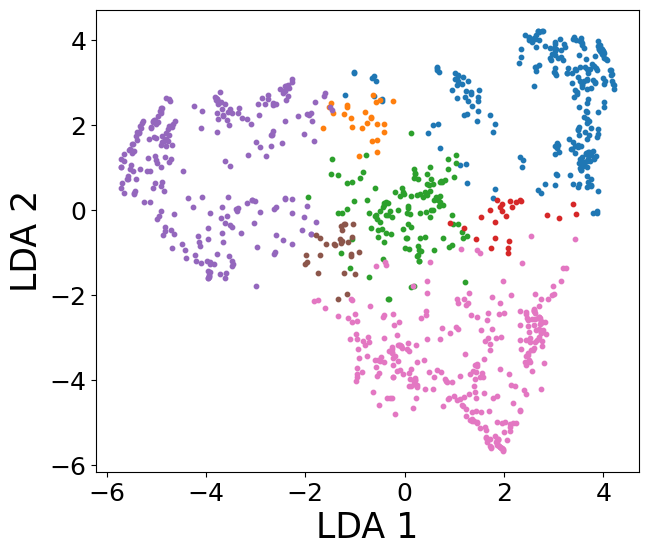

In [18]:
points = vecs_lda_2d[:, -1, :] 
labels = state_2d[:, -1]       

plt.figure(figsize=(7, 6))

for label in np.unique(labels):
    mask = labels == label

    plt.scatter(
        points[mask, 0],
        points[mask, 1],
        s=10,
        label=label
    )

plt.xlabel('LDA 1', fontsize = 25)
plt.ylabel('LDA 2', fontsize = 25)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.savefig(
    'LDA_10th_point.tif',
    format='tiff',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

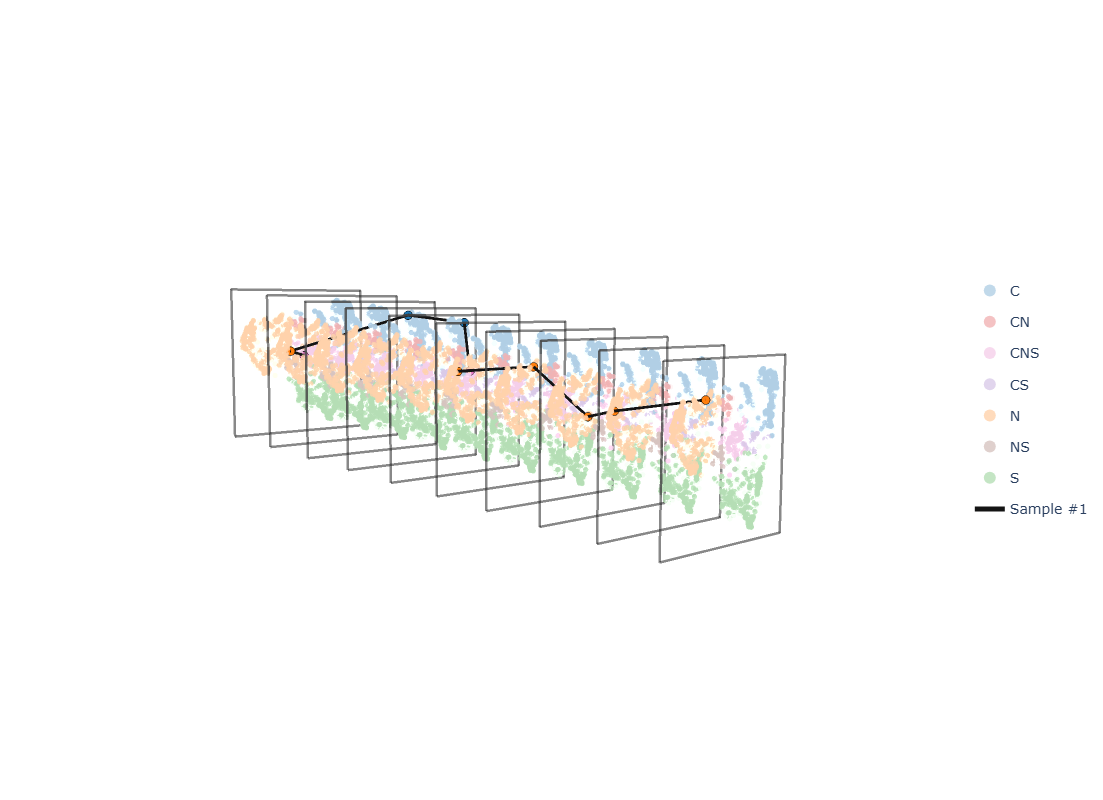

In [91]:
import numpy as np
import plotly.graph_objects as go

SAMPLE_IDX = 1         
LAYER_OPACITY  = 0                   
                                                                     
HI_LINE_COLOR  = 'rgb(20,20,20)'       
HI_LINE_WIDTH  = 6                    

BG_FADE          = 0.65               
BG_POINT_OPACITY = 0.8                 
BG_POINT_SIZE    = 3                   

LAYER_EDGE       = 'rgba(60,60,60,0.85)'  
LAYER_EDGE_WIDTH = 5                      

traj_xy    = vecs_lda_2d[SAMPLE_IDX]            
traj_state = np.asarray(state_2d)[SAMPLE_IDX]    

def layer_to_trial(t):
    return 9 - t

points = vecs_lda_2d[:, 9, :]                
labels = np.asarray(state_2d)[:, 9]          

color_map = {
    'C':   '#1f77b4',
    'N':   '#ff7f0e',
    'S':   '#2ca02c',
    'CN':  '#d62728',
    'CS':  '#9467bd',
    'NS':  '#8c564b',
    'CNS': '#e377c2'
}


def fade_to_white(hex_color, w):
    hex_color = hex_color.lstrip('#')
    r, g, b = (int(hex_color[i:i + 2], 16) for i in (0, 2, 4))
    r = round(r + (255 - r) * w)
    g = round(g + (255 - g) * w)
    b = round(b + (255 - b) * w)
    return f'rgb({r},{g},{b})'

bg_color_map = {k: fade_to_white(v, BG_FADE) for k, v in color_map.items()}

INCLUDE_TRAJ_IN_RANGE = True

x = points[:, 0]
y = points[:, 1]

if INCLUDE_TRAJ_IN_RANGE:
    x_all = np.concatenate([x, traj_xy[:, 0]])
    y_all = np.concatenate([y, traj_xy[:, 1]])
else:
    x_all, y_all = x, y

x_min, x_max = x_all.min(), x_all.max()
y_min, y_max = y_all.min(), y_all.max()

x_range = x_max - x_min
y_range = y_max - y_min

x_center = (x_min + x_max) / 2
y_center = (y_min + y_max) / 2

pad_ratio = 0.08

x_min_pad = x_min - x_range * pad_ratio
x_max_pad = x_max + x_range * pad_ratio

y_min_pad = y_min - y_range * pad_ratio
y_max_pad = y_max + y_range * pad_ratio

max_range = max(
    x_max_pad - x_min_pad,
    y_max_pad - y_min_pad
)

scale = 2.4 / max_range


def to_local_xy(x_in, y_in):
    u = (np.asarray(x_in) - x_center) * scale
    v = (np.asarray(y_in) - y_center) * scale
    return u, v


u_pts, v_pts = to_local_xy(x, y)
u_min, v_min = to_local_xy(x_min_pad, y_min_pad)
u_max, v_max = to_local_xy(x_max_pad, y_max_pad)

theta = np.deg2rad(20)

u_vec = np.array([np.cos(theta), np.sin(theta), 0])
v_vec = np.array([0, 0, 1])
normal_vec = np.array([np.sin(theta), -np.cos(theta), 0])
back_vec = -normal_vec

shift_left = 0.24
shift_up = 0.10
shift_back = 0.8

def get_layer_center(t):
    return (
        -t * shift_left * u_vec
        + t * shift_up * v_vec
        + t * shift_back * back_vec
    )

CAM_AZIM = -38  
CAM_ELEV = 0.10    
CAM_DIST = 2.45    

_a = np.deg2rad(CAM_AZIM)
cam_eye = np.cos(_a) * normal_vec + np.sin(_a) * u_vec + CAM_ELEV * v_vec
cam_eye = cam_eye / np.linalg.norm(cam_eye) * CAM_DIST


def layer_depth(t):

    return float(np.dot(get_layer_center(t), cam_eye))

def local_to_3d(u, v, center):
    u = np.asarray(u)
    v = np.asarray(v)

    x3d = center[0] + u * u_vec[0] + v * v_vec[0]
    y3d = center[1] + u * u_vec[1] + v * v_vec[1]
    z3d = center[2] + u * u_vec[2] + v * v_vec[2]

    return x3d, y3d, z3d

fig = go.Figure()

legend_added = set()

draw_order = sorted(range(10), key=layer_depth) 

hi_x, hi_y, hi_z = [], [], []
hi_color, hi_state, hi_trial = [], [], []

for t in draw_order:

    center = get_layer_center(t)
    
    corner_u = np.array([u_min, u_max, u_max, u_min])
    corner_v = np.array([v_min, v_min, v_max, v_max])

    cx, cy, cz = local_to_3d(corner_u, corner_v, center)

    if LAYER_OPACITY > 0:
        fig.add_trace(
            go.Mesh3d(
                x=cx,
                y=cy,
                z=cz,
                i=[0, 0],
                j=[1, 2],
                k=[2, 3],
                color='white',
                opacity=LAYER_OPACITY,
                flatshading=True,
                hoverinfo='skip',
                showlegend=False
            )
        )

    border_x = np.append(cx, cx[0])
    border_y = np.append(cy, cy[0])
    border_z = np.append(cz, cz[0])

    fig.add_trace(
        go.Scatter3d(
            x=border_x,
            y=border_y,
            z=border_z,
            mode='lines',
            line=dict(
                color=LAYER_EDGE,
                width=LAYER_EDGE_WIDTH
            ),
            hoverinfo='skip',
            showlegend=False
        )
    )

    px, py, pz = local_to_3d(u_pts, v_pts, center)

    for label in np.unique(labels):
        mask = labels == label

        show_legend = label not in legend_added

        fig.add_trace(
            go.Scatter3d(
                x=px[mask],
                y=py[mask],
                z=pz[mask],
                mode='markers',
                marker=dict(
                    size=BG_POINT_SIZE,
                    color=bg_color_map.get(label, 'rgb(210,210,210)'),
                    opacity=BG_POINT_OPACITY,
                    line=dict(width=0)
                ),
                name=label,
                legendgroup=label,
                showlegend=show_legend,
                hovertemplate=(
                    f'State: {label}<br>'
                    f'Layer copy: {t+1}'
                    '<extra></extra>'
                )
            )
        )

        legend_added.add(label)
        
    k = layer_to_trial(t)

    hu, hv = to_local_xy(traj_xy[k, 0], traj_xy[k, 1])
    hx, hy, hz = local_to_3d(hu, hv, center)

    s_label = traj_state[k]

    hi_x.append(float(hx))
    hi_y.append(float(hy))
    hi_z.append(float(hz))
    hi_color.append(color_map.get(s_label, '#000000'))
    hi_state.append(str(s_label))
    hi_trial.append(k + 1)

fig.add_trace(
    go.Scatter3d(
        x=hi_x,
        y=hi_y,
        z=hi_z,
        mode='lines',
        line=dict(
            color=HI_LINE_COLOR,
            width=HI_LINE_WIDTH
        ),
        name=f'Sample #{SAMPLE_IDX}',
        legendgroup='highlight',
        showlegend=True,
        hoverinfo='skip'
    )
)

fig.add_trace(
    go.Scatter3d(
        x=hi_x,
        y=hi_y,
        z=hi_z,
        mode='markers',
        marker=dict(
            size=5,
            color=hi_color,
            opacity=1.0,
            line=dict(color='black', width=2)
        ),
        name=f'Sample #{SAMPLE_IDX}',
        legendgroup='highlight',
        showlegend=False,
        customdata=np.stack([hi_trial, hi_state], axis=-1),
        hovertemplate=(
            f'Sample #{SAMPLE_IDX}<br>'
            'Trial: %{customdata[0]}<br>'
            'State: %{customdata[1]}'
            '<extra></extra>'
        )
    )
)

fig.update_layout(
    width=1100,
    height=800,
    margin=dict(l=10, r=130, t=10, b=10),

    legend=dict(
        x=1.02,
        y=0.5,
        xanchor='left',
        yanchor='middle',
        bgcolor='rgba(255,255,255,0)',
        font=dict(size=14),
        itemsizing='constant'
    ),

    scene=dict(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False),
        aspectmode='data',
        camera=dict(
            eye=dict(x=cam_eye[0], y=cam_eye[1], z=cam_eye[2]),
            up=dict(x=0, y=0, z=1),
            projection=dict(type='perspective')
        ),
        bgcolor='rgba(255,255,255,0)'
    ),

    paper_bgcolor='white',
    plot_bgcolor='white'
)

fig.show()

export scale = 3.818  ->  4200 x 3055 px


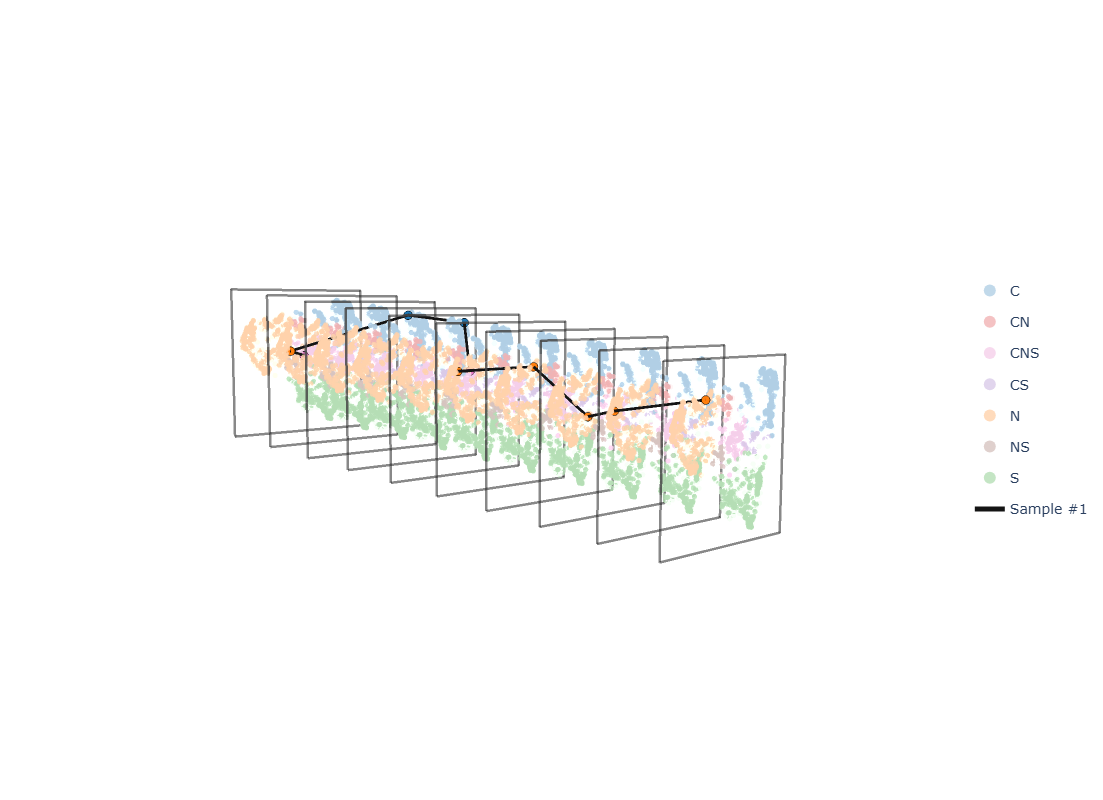

In [92]:
TARGET_WIDTH_IN  = 7.0     
TARGET_DPI       = 600

FIG_W, FIG_H = 1100, 800   

target_px = TARGET_WIDTH_IN * TARGET_DPI          
export_scale = target_px / FIG_W                  

print(f"export scale = {export_scale:.3f}  ->  "
      f"{round(FIG_W*export_scale)} x {round(FIG_H*export_scale)} px")

config = {
    'toImageButtonOptions': {
        'format': 'png',          
        'filename': 'layers_view',
        'width':  FIG_W,          
        'height': FIG_H,
        'scale':  export_scale  
    },
    'displaylogo': False
}

fig.show(config=config)

In [95]:
# ============================================================
# [저장 2단계] 내려받은 PNG -> 600 dpi TIFF 변환
#
#   dpi 는 픽셀 수를 바꾸지 않고 "몇 인치로 인쇄할지" 메타데이터만
#   기록하는 값이다. 실제 해상도는 1단계의 export_scale 이 결정한다.
# ============================================================

from pathlib import Path
from PIL import Image

PNG_PATH = Path.home() / 'Downloads' / 'layers_view.png'   # 다운로드된 파일 경로
TIF_PATH = Path('results') / 'layers_view.tif'             # 저장할 경로
DPI      = 600

img = Image.open(PNG_PATH)

# 투명 배경이면 흰 배경 위에 합성 (TIFF/인쇄용)
if img.mode in ('RGBA', 'LA'):
    bg = Image.new('RGB', img.size, 'white')
    bg.paste(img, mask=img.split()[-1])
    img = bg
else:
    img = img.convert('RGB')

TIF_PATH.parent.mkdir(parents=True, exist_ok=True)

img.save(
    TIF_PATH,
    format='TIFF',
    dpi=(DPI, DPI),
    compression='tiff_lzw' 
)

w, h = img.size
print(f'saved: {TIF_PATH}')
print(f'{w} x {h} px  @ {DPI} dpi  ->  {w/DPI:.2f} x {h/DPI:.2f} inch')


saved: results\layers_view.tif
4200 x 3054 px  @ 600 dpi  ->  7.00 x 5.09 inch
